<a href="https://colab.research.google.com/github/PedroHS05/Prova-Aprendizagem-de-Maquina-Fatec-2026/blob/main/ProvaFinalizada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline | MEC Bolsas ProUni [Atividade 31]

##1. Importar dados do Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Bibliotecas de Python

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils import resample

##3. Carregar e Tratar Base ProUni

In [4]:
# Caminho do arquivo original no Drive
path = '/content/drive/MyDrive/provaicoma/ProuniRelatorioDadosAbertos2020.csv'
base = pd.read_csv(path, sep=';', encoding='latin1')

In [5]:
# Tratamento de Nulos (Limpando a base para ingestão)
base = base.dropna()

In [6]:
# Engenharia de Variáveis: Alvo (Y) - Bolsa Integral (1) vs Parcial (0)
base['Y'] = base['TIPO_BOLSA'].apply(lambda x: 1 if 'INTEGRAL' in str(x).upper() else 0)

## 4. Transformação de Variáveis (Qualitativas Ordinais e Nominais)

In [7]:
# Transformação Ordinal (Dando hierarquia aos turnos)
mapeamento_turno = {'CURSO A DISTÂNCIA': 0, 'MATUTINO': 1, 'VESPERTINO': 2, 'NOTURNO': 3, 'INTEGRAL': 4}
base['NOME_TURNO_CURSO_BOLSA'] = base['NOME_TURNO_CURSO_BOLSA'].map(mapeamento_turno)

In [8]:
# Encoding de Variáveis Nominais
le = LabelEncoder()
colunas_nominais = ['MODALIDADE_ENSINO_BOLSA', 'SEXO_BENEFICIARIO', 'RACA_BENEFICIARIO', 'REGIAO_BENEFICIARIO']
for col in colunas_nominais:
    base[col] = le.fit_transform(base[col])

## 5. Balanceamento de Base (Downsampling)

Ajuste necessário para evitar o viés do algoritmo

In [9]:
# Separando as classes
df_parcial = base[base['Y'] == 0]
df_integral = base[base['Y'] == 1]

In [10]:
# Reduzindo a classe majoritária (Integral) para igualar à minoritária
df_integral_downsampled = resample(df_integral, replace=False, n_samples=len(df_parcial), random_state=42)

In [11]:
# Concatenando a base equilibrada
base_final = pd.concat([df_integral_downsampled, df_parcial])

## 6. Visualização de Dados

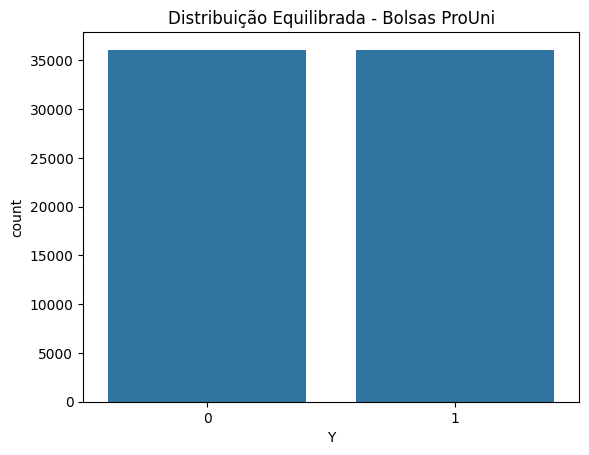

In [12]:
# Verificação do equilíbrio de classes
sns.countplot(x='Y', data=base_final)
plt.title('Distribuição Equilibrada - Bolsas ProUni')
plt.show()

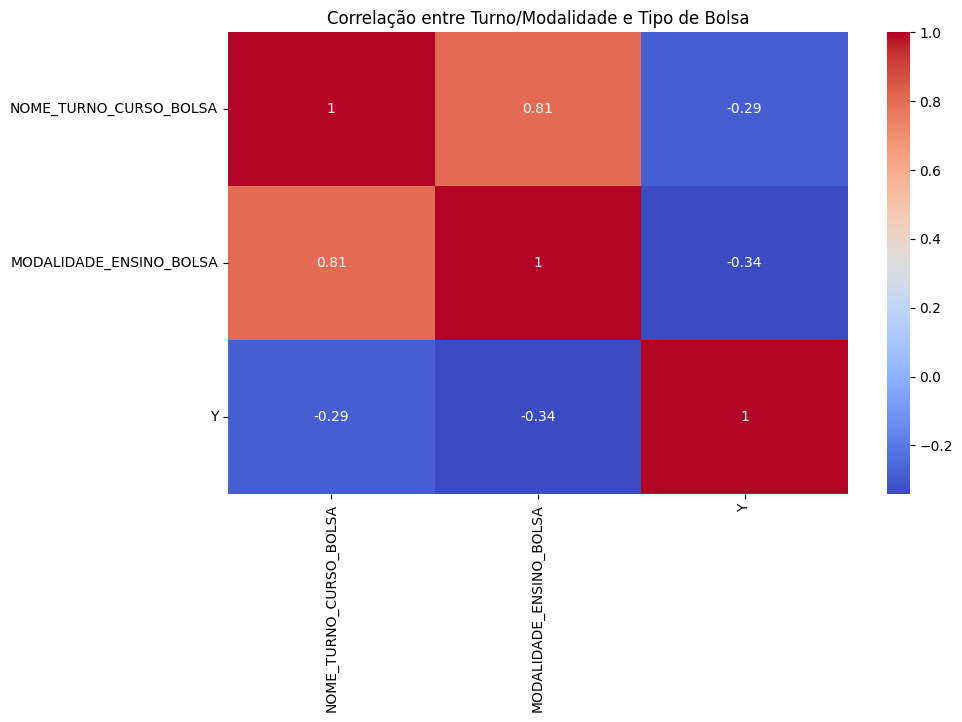

In [13]:
# Matriz de Correlação
plt.figure(figsize=(10,6))
sns.heatmap(base_final[['NOME_TURNO_CURSO_BOLSA', 'MODALIDADE_ENSINO_BOLSA', 'Y']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlação entre Turno/Modalidade e Tipo de Bolsa')
plt.show()

## 7. Ingestão Bayesiana e Normalização

In [14]:
# Definindo preditores e alvo
X = base_final[['NOME_TURNO_CURSO_BOLSA', 'MODALIDADE_ENSINO_BOLSA', 'SEXO_BENEFICIARIO', 'REGIAO_BENEFICIARIO']]
y = base_final['Y']

In [15]:
# Split de Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [16]:
# Normalização StandardScaler (Padrão Icoma para GaussianNB)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
# Treinamento do Modelo Gaussian Naive Bayes
naive_prouni = GaussianNB()
naive_prouni.fit(X_train_scaled, y_train)

GaussianNB()

##8. Avaliação do Modelo e Métricas de Performance

In [18]:
# Previsões
y_pred = naive_prouni.predict(X_test_scaled)

In [19]:
# Métricas Finais
print(f"Acurácia: {accuracy_score(y_test, y_pred):.2f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

Acurácia: 0.65

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.60      0.91      0.72     10841
           1       0.80      0.38      0.52     10808

    accuracy                           0.65     21649
   macro avg       0.70      0.65      0.62     21649
weighted avg       0.70      0.65      0.62     21649



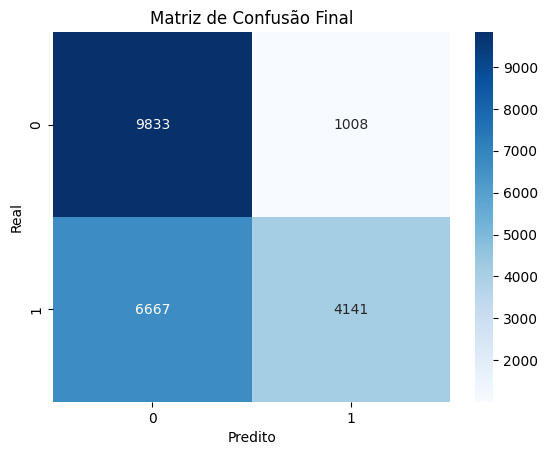

In [20]:
# Matriz de Confusão Visual
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão Final')
plt.show()